# Smart Agriculture Assistant

## Crop Yield Prediction Model

This notebook develops a machine learning model for predicting crop yield using environmental and soil-related factors.

The goal is to help farmers estimate expected production before harvesting and support better agricultural decision-making.

----

# Import Required Libraries

In this section, we import all libraries required for data analysis, preprocessing, visualization, machine learning, and model saving.

These libraries provide the tools needed throughout the yield prediction pipeline.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

import joblib

---

# Load Dataset

Load the crop yield dataset into a Pandas DataFrame.

In [2]:
df = pd.read_csv("crop_yield_dataset.csv")

df.head()

,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
0,2014-01-01,Wheat,Peaty,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333
1,2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
2,2014-01-01,Rice,Peaty,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333
3,2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
4,2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667


---

# Dataset Overview

This section examines:

- Number of records
- Data types
- Missing values
- Statistical summary

In [3]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (36520, 12)
<class 'pandas.DataFrame'>
RangeIndex: 36520 entries, 0 to 36519
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          36520 non-null  str    
 1   Crop_Type     36520 non-null  str    
 2   Soil_Type     36520 non-null  str    
 3   Soil_pH       36520 non-null  float64
 4   Temperature   36520 non-null  float64
 5   Humidity      36520 non-null  float64
 6   Wind_Speed    36520 non-null  float64
 7   N             36520 non-null  float64
 8   P             36520 non-null  float64
 9   K             36520 non-null  float64
 10  Crop_Yield    36520 non-null  float64
 11  Soil_Quality  36520 non-null  float64
dtypes: float64(9), str(3)
memory usage: 3.3 MB


---

# Missing Value Analysis

Missing values can negatively impact model performance.

This section identifies incomplete records.

In [4]:
df.isnull().sum()

Date            0
Crop_Type       0
Soil_Type       0
Soil_pH         0
Temperature     0
Humidity        0
Wind_Speed      0
N               0
P               0
K               0
Crop_Yield      0
Soil_Quality    0
dtype: int64

----

# Duplicate Record Analysis

In [5]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


---

# Crop Type Analysis

The Crop_Type column is examined to determine available crops.

In [6]:
print(df["Crop_Type"].unique())

<StringArray>
[    'Wheat',      'Corn',      'Rice',    'Barley',   'Soybean',    'Cotton',
 'Sugarcane',    'Tomato',    'Potato', 'Sunflower']
Length: 10, dtype: str


---

# Crop Yield Distribution

This visualization shows how crop yield values are distributed across the dataset.

Understanding the target variable helps identify patterns, outliers, and data balance.

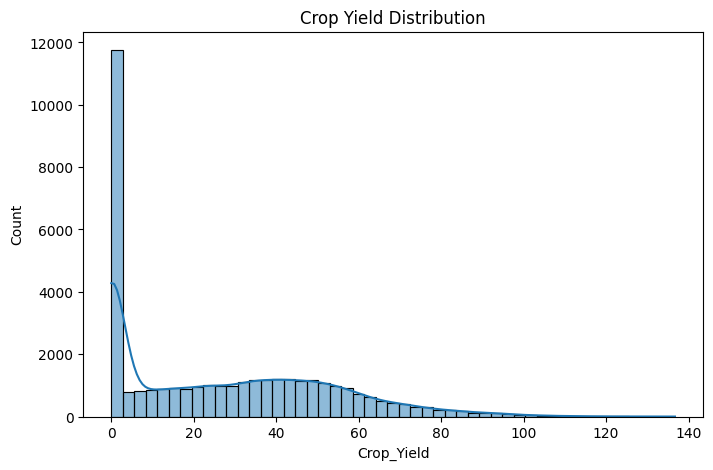

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["Crop_Yield"], kde=True)

plt.title("Crop Yield Distribution")

plt.show()

# Crop Type Analysis

This chart displays the number of records available for each crop type.

It helps us understand the representation of different crops within the dataset.

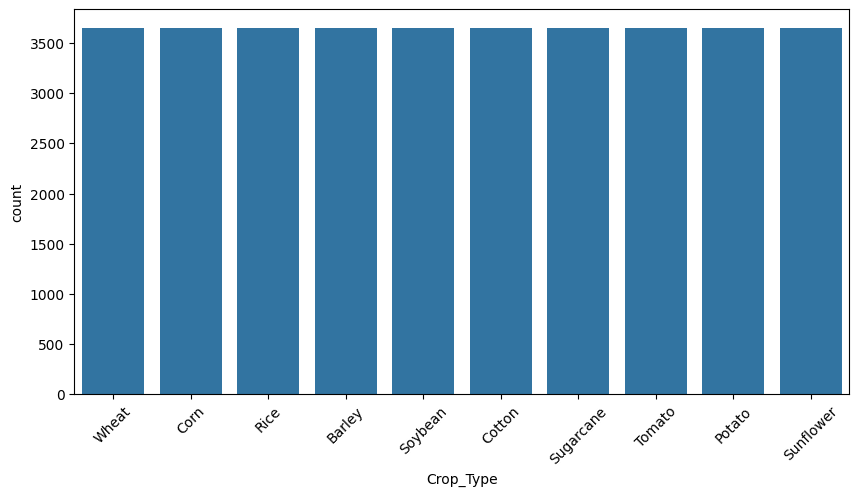

In [8]:
plt.figure(figsize=(10,5))

sns.countplot(x=df["Crop_Type"])

plt.xticks(rotation=45)

plt.show()

# Correlation Matrix

A correlation matrix is used to analyze relationships between numerical features.

This helps identify which factors may have a stronger influence on crop yield.

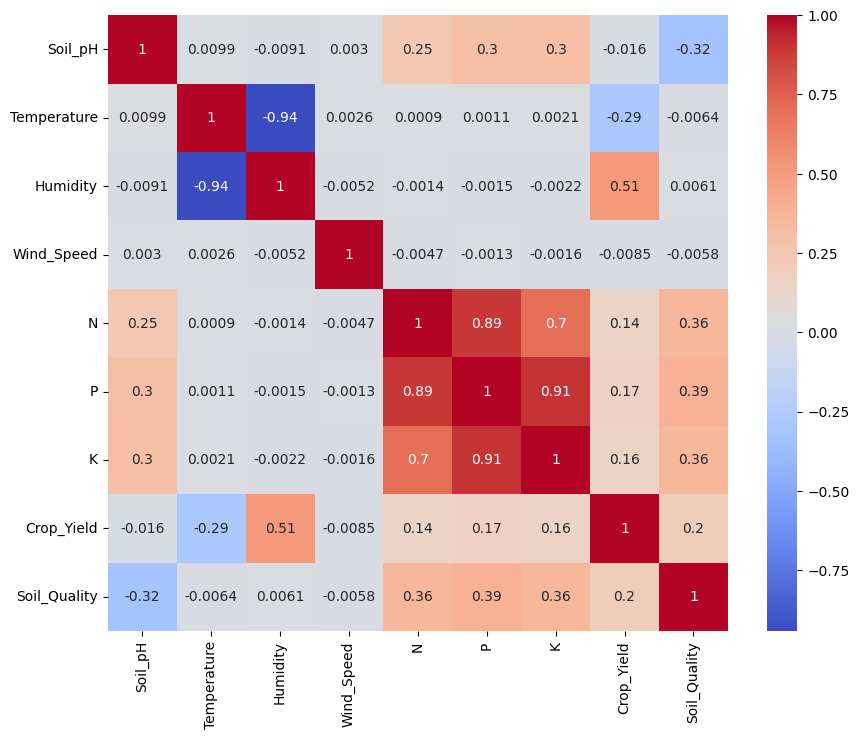

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Convert Categorical Features

Machine learning models cannot directly process text-based categories.

Categorical features such as crop type and soil type are converted into numerical values using label encoding.

In [10]:
crop_encoder = LabelEncoder()

soil_encoder = LabelEncoder()

df["Crop_Type"] = crop_encoder.fit_transform(
    df["Crop_Type"]
)

df["Soil_Type"] = soil_encoder.fit_transform(
    df["Soil_Type"]
)

# Save Label Encoders

The trained encoders are saved for future use during deployment.

This ensures consistent conversion of categorical inputs when predicting new crop yields.

In [11]:
joblib.dump(
    crop_encoder,
    "crop_encoder.pkl"
)

joblib.dump(
    soil_encoder,
    "soil_encoder.pkl"
)

['soil_encoder.pkl']

# Feature Selection

The dataset is divided into input features and the target variable.

Input features are used to make predictions, while crop yield serves as the prediction target.

In [12]:
X = df.drop(
    columns=[
        "Crop_Yield",
        "Date"
    ]
)
y = df["Crop_Yield"]

# Feature Scaling

Features may have different numerical ranges which can affect model performance.

Standardization is applied to bring all features onto a similar scale.

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

joblib.dump(
    scaler,
    "yield_scaler.pkl"
)

['yield_scaler.pkl']

# Split Dataset

The dataset is divided into training and testing subsets.

Training data is used to learn patterns, while testing data evaluates model performance on unseen samples.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Random Forest Regression Model

A Random Forest Regressor is selected for crop yield prediction.

This algorithm is robust, accurate, and performs well on agricultural datasets containing multiple features.

In [16]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# Yield Prediction

The trained model is used to predict crop yield for the testing dataset.

These predictions will be compared with actual values to evaluate model performance.

In [17]:
predictions = model.predict(
    X_test
)

# Model Evaluation

Several evaluation metrics are calculated to measure prediction accuracy.

These metrics help determine how effectively the model predicts crop yield.

# Mean Absolute Error (MAE)

MAE measures the average difference between actual and predicted crop yield values.

Lower MAE values indicate better prediction performance.

In [18]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print("MAE:", mae)

MAE: 2.3758943260279417


# Root Mean Squared Error (RMSE)

RMSE measures prediction error while giving greater importance to larger mistakes.

Lower RMSE values indicate a more accurate model.

In [19]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 4.097393293079604


# R² Score

The R² score measures how well the model explains the variation in crop yield.

Values closer to 1 indicate better predictive performance.

In [20]:
r2 = r2_score(
    y_test,
    predictions
)

print("R2 Score:", r2)

R2 Score: 0.9748231428702243


# Feature Importance

Random Forest provides information about the relative importance of each feature.

This helps identify which environmental and soil factors most strongly influence crop yield.

In [21]:
importance = model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

        Feature  Importance
3   Temperature    0.581639
4      Humidity    0.151547
9  Soil_Quality    0.096492
0     Crop_Type    0.070378
6             N    0.057607
7             P    0.026293
5    Wind_Speed    0.008316
1     Soil_Type    0.003335
8             K    0.003274
2       Soil_pH    0.001119


# Feature Importance Visualization

A graphical representation of feature importance is generated.

This visualization helps understand the key factors affecting crop productivity.

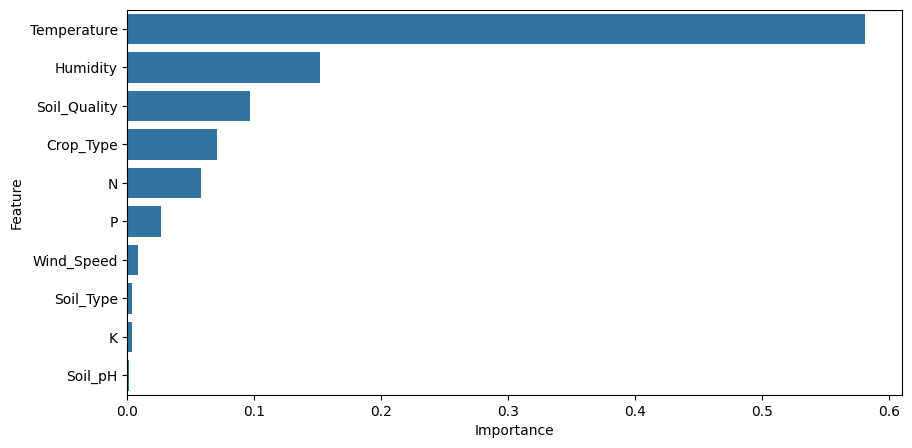

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.show()

# Compare Actual vs Predicted Values

In [39]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(20)

,Actual,Predicted
0,43.773844,50.021016
1,47.154682,44.956383
2,50.594471,49.735315
3,34.482595,29.845412
4,0.000000,0.000000
5,50.560916,48.526441
6,54.136219,55.150775
7,41.729770,37.505597
8,0.000000,0.000000
9,0.000000,0.000000


# Calculate Percentage Error

In [23]:
mask = y_test != 0

error_percentage = (
    np.abs(y_test[mask] - predictions[mask]) / y_test[mask]
) * 100

print("Average Error %:", error_percentage.mean())

Average Error %: 9.304277988527366


# Plot Actual vs Predicted

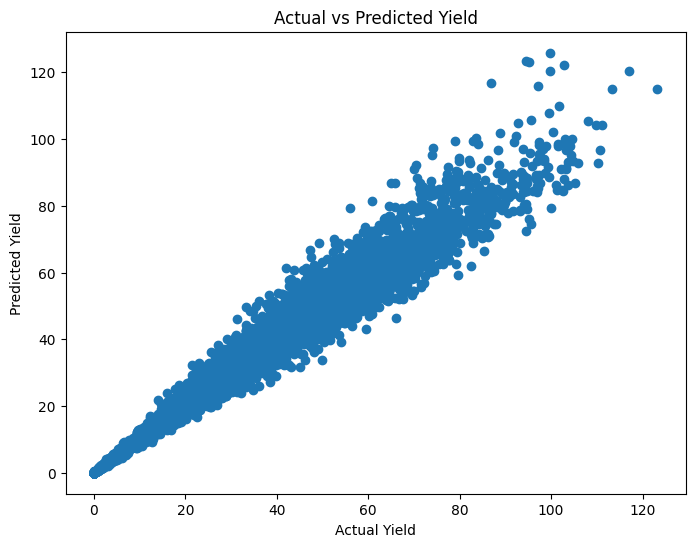

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield")

plt.show()

# Check Overfitting

In [24]:
train_score = model.score(
    X_train,
    y_train
)

test_score = model.score(
    X_test,
    y_test
)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.9966860725392301
Test R² : 0.9748231428702243


# Cross Validation

To verify the model's reliability, 5-fold cross validation was performed.

The model achieved an average R² score of 0.9758, indicating strong and consistent predictive performance across different subsets of the dataset.

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Average R²:", scores.mean())

[0.97413804 0.97584974 0.97503632 0.97651914 0.97703443]
Average R²: 0.9757155323394091


# Save Trained Model

The trained yield prediction model is saved for future use.

The saved model can later be integrated into the Smart Agriculture Assistant application.

In [26]:
joblib.dump(
    model,
    "yield_prediction_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


# Project Summary

The crop yield prediction pipeline has been successfully completed.

The project included data preprocessing, visualization, feature engineering, model training, evaluation, and model saving.

The trained model is now ready for deployment and integration into the Smart Agriculture Assistant system.

In [27]:
from sklearn.metrics import r2_score

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

Train R²: 0.9966860725392301
Test R² : 0.9748231428702243
